In [65]:
# Importing Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [46]:
# Loading data

data = pd.read_csv('Cali.csv')

data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [47]:
# Dataset Information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [48]:
# Data Stats

data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [49]:
# Data cleaning

data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

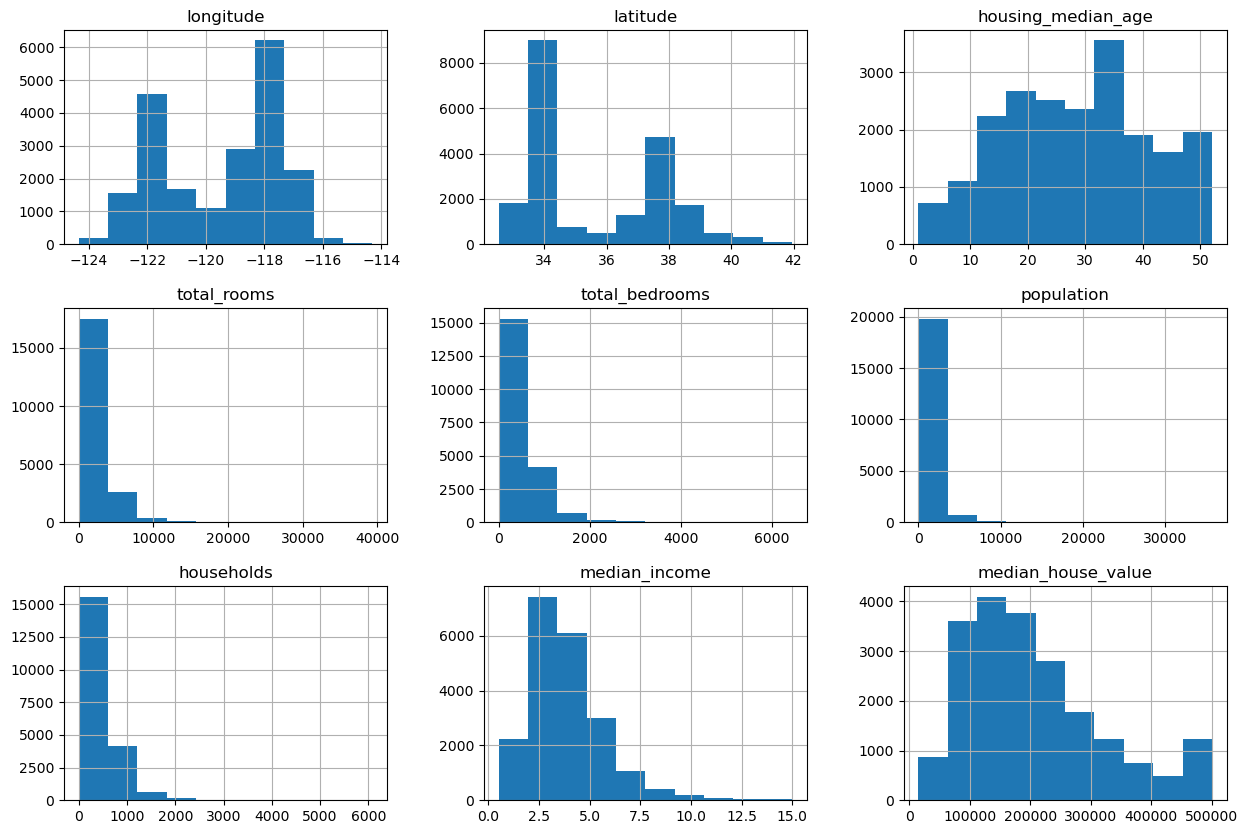

In [50]:
# Histogram of Variables

data.hist(
    figsize=(15,10)
)

plt.show()

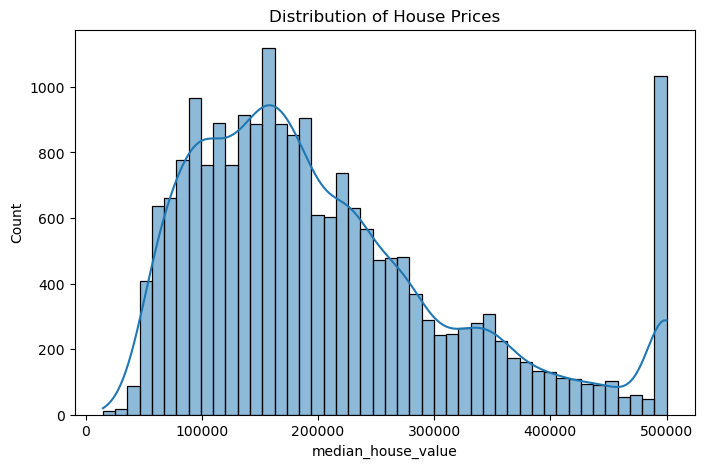

In [51]:
# House Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data['median_house_value'],
    kde=True
)

plt.title(
    'Distribution of House Prices'
)

plt.show()

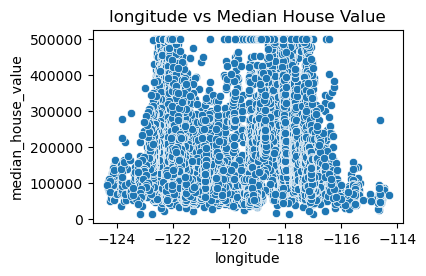

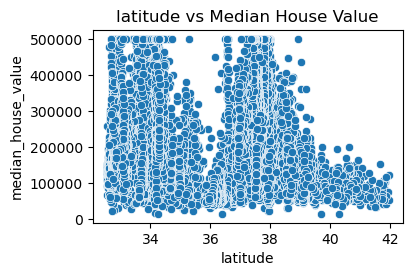

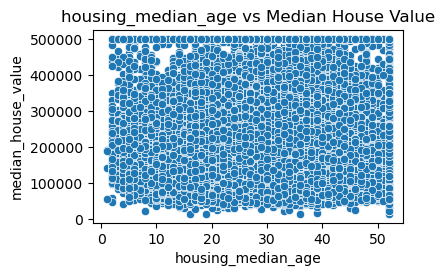

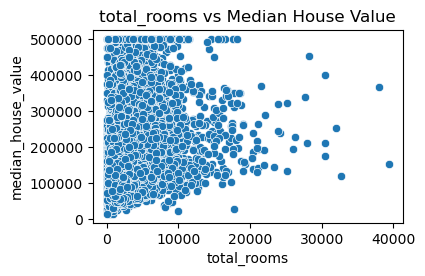

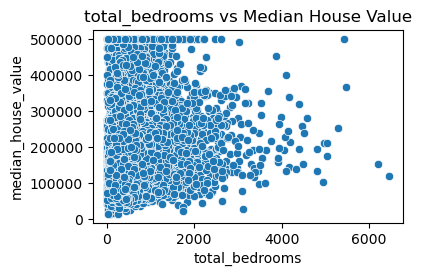

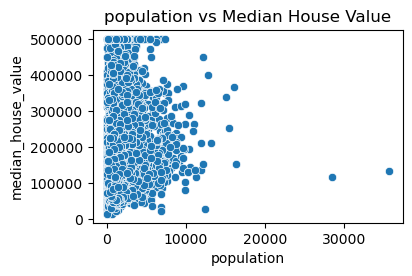

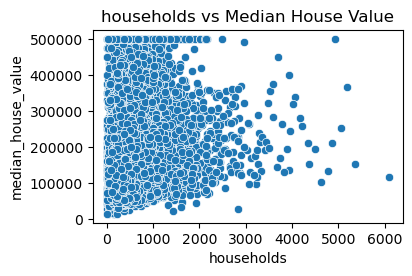

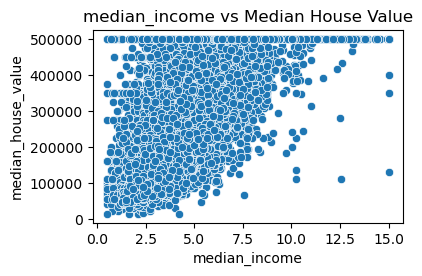

In [52]:
# Scatter Plots

features = [

    'longitude',

    'latitude',

    'housing_median_age',

    'total_rooms',

    'total_bedrooms',

    'population',

    'households',

    'median_income'

]

for feature in features:

    plt.figure(figsize=(4,2.5))

    sns.scatterplot(

        data=data,

        x=feature,

        y='median_house_value'

    )

    plt.title(
        feature +
        ' vs Median House Value'
    )

    plt.show()

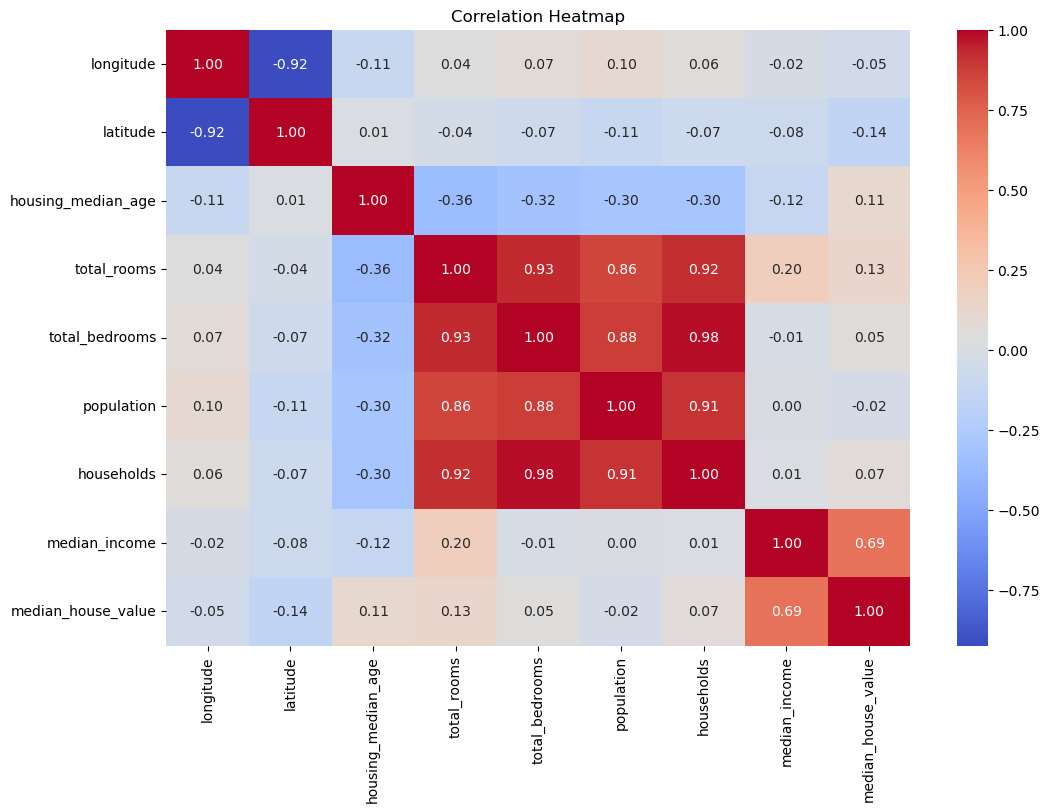

In [53]:
# Heatmap

plt.figure(
    figsize=(12,8)
)

sns.heatmap(

    data.corr(
        numeric_only=True
    ),

    annot=True,

    cmap='coolwarm',

    fmt='.2f'

)

plt.title(
    'Correlation Heatmap'
)

plt.show()

In [76]:
# Convertion of Variable

ocean_cols = [col for col in data.columns if 'ocean' in col.lower() or 'proximity' in col.lower()]
print("Ocean/proximity columns found:", ocean_cols)

Ocean/proximity columns found: ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [77]:
#Data features

print("Available columns:", data.columns.tolist())

data['rooms_per_household'] = data['total_rooms'] / data['households']
data['bedrooms_per_room'] = data['total_bedrooms'] / data['total_rooms']
data['population_per_household'] = data['population'] / data['households']

available_features = []
desired_features = [
    'median_income',
    'housing_median_age', 
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household',
    'ocean_proximity_INLAND',
    'ocean_proximity_ISLAND',
    'ocean_proximity_NEAR BAY',
    'ocean_proximity_NEAR OCEAN'
]

for feature in desired_features:
    available_features.append(feature)

x = data[available_features]
y = data['median_house_value']



Available columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


In [78]:
# Normalization

scaler = StandardScaler()

x = scaler.fit_transform(
    x
)

In [79]:
# Train Test Split

x_train, x_test, y_train, y_test = train_test_split(

    x,

    y,

    test_size=0.2,

    random_state=42

)

In [80]:
# Linear Regression Model

OLS = LinearRegression()

OLS.fit(

    x_train,

    y_train

)

LinearRegression()

In [67]:
# Predictions

x_test_clean = pd.DataFrame(x_test).dropna()
y_pred = OLS.predict(x_test_clean)

In [81]:
# Model Evaluation

print(
    f'y_test shape: {y_test.shape}, y_pred shape: {y_pred.shape}'
)


min_length = min(len(y_test), len(y_pred))
y_test_aligned = y_test[:min_length]  
y_pred_aligned = y_pred[:min_length]  

print(
    'Mean Absolute Error'
)

print(
    mean_absolute_error(
        y_test_aligned,  
        y_pred_aligned  
    )
)

print()

print(
    'Root Mean Squared Error'
)

print(
    np.sqrt(
        mean_squared_error(
            y_test_aligned,  
            y_pred_aligned   
        )
    )
)

print()

print(
    'R2 Score'
)

print(
    r2_score(
        y_test_aligned,  
        y_pred_aligned   
    )
)

y_test shape: (4128,), y_pred shape: (3921,)
Mean Absolute Error
114450.26830061672

Root Mean Squared Error
146915.5219161082

R2 Score
-0.6502099836434518


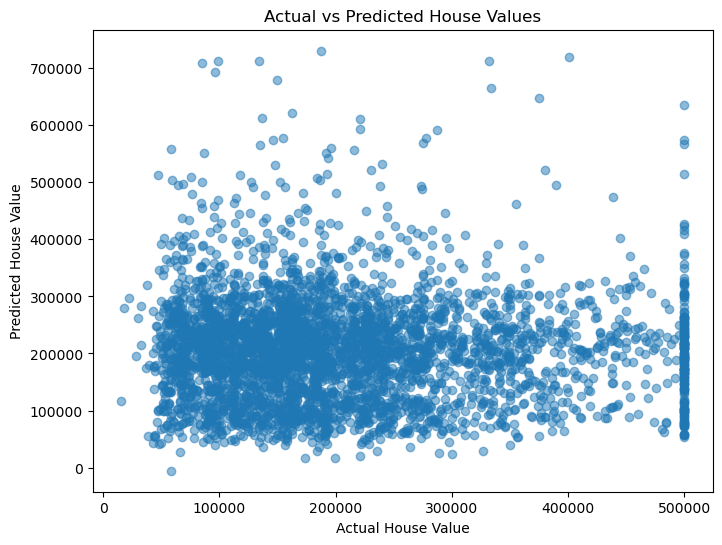

In [73]:
# Actual vs Predicted Values

plt.figure(
    figsize=(8,6)
)

plt.scatter(
    y_test[:len(y_pred)],
    y_pred,
    alpha=0.5
)

plt.xlabel(
    'Actual House Value'
)

plt.ylabel(
    'Predicted House Value'
)

plt.title(
    'Actual vs Predicted House Values'
)

plt.show()

In [75]:
# Feature Importance

coefficients = pd.DataFrame(

    {

        'Feature': [

            'median_income',

            'housing_median_age',

            'rooms_per_household',

            'bedrooms_per_room',

            'population_per_household',

            'ocean_proximity_INLAND',

            'ocean_proximity_ISLAND',

            'ocean_proximity_NEAR BAY',

            'ocean_proximity_NEAR OCEAN'

        ],

        'Coefficient': OLS.coef_

    }

)

coefficients.sort_values(

    by='Coefficient',

    ascending=False

)

,Feature,Coefficient
0,median_income,84145.687107
3,bedrooms_per_room,19174.774923
1,housing_median_age,12377.507291
8,ocean_proximity_NEAR OCEAN,5813.349342
2,rooms_per_household,5435.506443
7,ocean_proximity_NEAR BAY,4362.393244
6,ocean_proximity_ISLAND,2455.314451
4,population_per_household,-3687.751959
5,ocean_proximity_INLAND,-29196.242008
